In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from arch import arch_model
import datetime as dt
from tensorflow import keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from numpy.random import seed
#from tensorflow import set_random_seed
import tensorflow
from keras.models import load_model

In [2]:
from keras.layers import Dropout

In [3]:
stocks = ['China','Hongkong','Indonesia','Japan','Korea','Singapore']
full_data = {}

for stock in stocks:
    full_data[stock] = pd.read_csv(f'/Users/khai/Desktop/Thesis_Asia_v2/DataSet/{stock}.csv',parse_dates=['Date'],
                                        index_col=['Date'])

DEMO

In [4]:
start = dt.datetime(2011,2,1)
end = dt.datetime(2021,12,31)
split_date = dt.datetime(2020,12,31)
stock = 'China'
ctg = full_data[stock]
df = np.log(ctg[['Close']]).diff().dropna()*100

ret = df['Close']['2016-01-01':]
    #am = arch_model(ret,mean='AR',vol='Garch', p=1, o=0, q=1, dist='skewt')
am = arch_model(ret,mean='AR',lags=0,vol='EGARCH', p=1, o=0, q=1)
res = am.fit(last_obs=split_date,disp='off')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          AR - EGARCH Model Results                           
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -1749.49
Distribution:                  Normal   AIC:                           3506.98
Method:            Maximum Likelihood   BIC:                           3527.39
                                        No. Observations:                 1215
Date:                Thu, Feb 23 2023   Df Residuals:                     1214
Time:                        21:12:11   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const          0.0275  2.479e-02      1.107      0.268 [-2.114e-02,7.605e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0161  1.196e-02      1.347      0.178 [-7.333e-03,3.955e-02]
alpha[1]       0.2126  8.123e-02      2.618  8.856e-03    [5.342e-02,  0.372]
beta[1]        0.9806  1.097e-02     89.390      0.000      [  0.959,  1.002]
=============================================================================

Covariance estimator: robust
"""

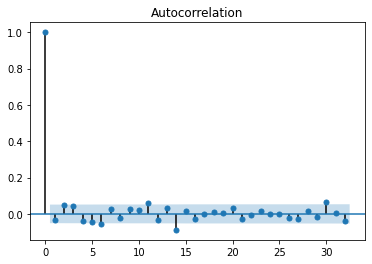

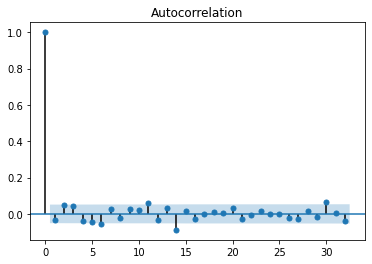

In [5]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plot_acf(ret)

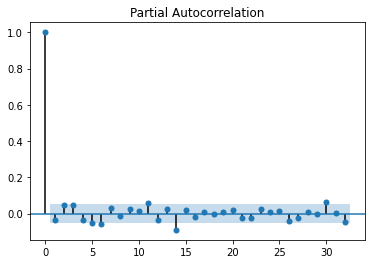

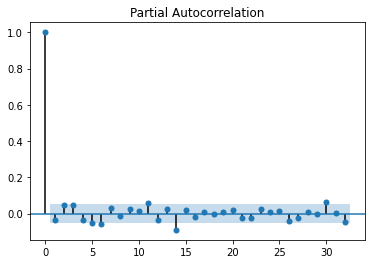

In [6]:
plot_pacf(ret)

In [ ]:
from statsmodels.tsa.arima_model import ARIMA
arima_model_fitted = ARIMA(ret, order=(1, 0, 1)).fit()
archm = arch_model(arima_model_fitted.resid, mean='Zero',vol='EGARCH', p=1, o=0, q=1)
arch_model_fitted = archm.fit()


In [19]:
arima_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              ARMA Model Results                              
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1464
Model:                     ARMA(1, 1)   Log Likelihood               -2269.482
Method:                       css-mle   S.D. of innovations              1.140
Date:                Sun, 27 Mar 2022   AIC                           4546.963
Time:                        16:16:13   BIC                           4568.119
Sample:                             0   HQIC                          4554.854
                                                                              
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0012      0.029      0.041      0.968      -0.055       0.058
ar.L1.Close    -0.3222      0.280     -1.149      0.250      -0.872       0.227
ma.L1.Close     0.2805      0.284      0.989      0.323      -0.275       0.836
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1           -3.1034           +0.0000j            3.1034            0.5000
MA.1           -3.5650           +0.0000j            3.5650            0.5000
-----------------------------------------------------------------------------
"""

In [4]:
# for stock in stocks:
#     print(full_data[stock].head())

In [18]:
start = dt.datetime(2011,2,1)
end = dt.datetime(2021,12,31)
split_date = dt.datetime(2020,12,31)
stock = 'Singapore'
ctg = full_data[stock]
df = np.log(ctg[['Close']]).diff().dropna()*100

ret = df['Close']['2011-02-01':'2021-12-31']
    #am = arch_model(ret,mean='AR',vol='Garch', p=1, o=0, q=1, dist='skewt')
am = arch_model(ret,mean='AR',lags=0,vol='EGARCH', p=1, o=0, q=1)
res = am.fit(last_obs=split_date,disp='off')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          AR - EGARCH Model Results                           
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -2807.72
Distribution:                  Normal   AIC:                           5623.43
Method:            Maximum Likelihood   BIC:                           5646.70
                                        No. Observations:                 2484
Date:                Sat, Feb 11 2023   Df Residuals:                     2483
Time:                        10:34:22   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const          0.0181  1.325e-02      1.368      0.171 [-7.844e-03,4.408e-02]
                               Volatility Model                               
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
omega      -8.0588e-03  5.295e-03     -1.522      0.128 [-1.844e-02,2.319e-03]
alpha[1]        0.2122  3.253e-02      6.524  6.855e-11      [  0.148,  0.276]
beta[1]         0.9734  7.627e-03    127.632      0.000      [  0.958,  0.988]
==============================================================================

Covariance estimator: robust
"""

In [7]:
start = dt.datetime(2011,2,1)
end = dt.datetime(2021,12,31)
split_date = dt.datetime(2020,12,31)
#ret = df['Close']

def implement_algo(stock):
    ctg = full_data[stock]
    df = np.log(ctg[['Close']]).diff().dropna()*100
    df['std'] = df['Close'].rolling(window=2, center=False).std()
    df['std'] = df['std']/np.sqrt(2) 
    df = df.dropna()
    df['target_vol'] = df['std'].shift(-1)
    df = df.dropna()
    
    df['ret_previous'] = df['Close'].shift(1)
    #df['square_log_previous'] = np.log(df['ret_previous']+1)**2
    df['std_previous'] = df['std'].shift(1)
    df = df.dropna()
    
    df_ind = ctg.copy()
    
    df_ind['spread'] = (df_ind['Open']-df_ind['Close'])/(df_ind['High']-df_ind['Low'])
    
    df_ind['Volume_diff'] = df_ind['Volume'].pct_change()
    df_ind_final = df_ind.loc[df.index,['spread','Volume_diff']]
    df = pd.concat([df,df_ind_final],axis=1)
    
    #### Fit the garch model #####
    
    df_train = df['2011-02-01':'2020-12-31']
    df_test = df['2021-01-01':]
    ret = df['Close']
    #am = arch_model(ret,mean='AR',vol='Garch', p=1, o=0, q=1, dist='skewt')
    am = arch_model(ret,mean='AR',vol='EGARCH', p=1, o=0, q=1)
    res = am.fit(last_obs=split_date,disp='off')
    res.summary()
    
    #### Use garch model to predict mean,vol ####
    forecasts_train = res.forecast(horizon=1, start=start)
    variance_pred = np.sqrt(forecasts_train.variance[start:].shift(1).dropna())
    mean_pred = forecasts_train.mean[start:]
    
    df_train['forecast_vol_garch'] = variance_pred[start:split_date]
    df_train['garch_mean'] = mean_pred[start:split_date]

    df_test['forecast_vol_garch'] = variance_pred[split_date:]
    df_test['garch_mean'] = mean_pred[split_date:]
    
    df_train = df_train.dropna() 
    df_train.replace([np.inf, -np.inf], 0, inplace=True)
    df_test.replace([np.inf, -np.inf], 0, inplace=True)
    
        #df_test = df_test.dropna()
    
    #### Build ANN Model ####
    
#     df_train['square_log_ret'] = np.log(df_train['Close']+1)**2
#     df_test['square_log_ret'] = np.log(df_test['Close']+1)**2
    
    X_train = df_train[['ret_previous','std_previous','forecast_vol_garch','spread','Volume_diff']].values
    y_train = df_train[['target_vol']].values

    X_test = df_test[['ret_previous','std_previous','forecast_vol_garch','spread','Volume_diff']].values
    y_test = df_test[['target_vol']].values
    
    model = get_model(X_train)
    model.compile(optimizer = 'adam', loss = 'mse')

    print("Training started..., this can take a while:")
    
    

    # Fit your model on your data for 30 epochs
    h_callback = model.fit(X_train,y_train, epochs = 100, validation_split = 0.2,batch_size=20)
    model.save(f'my_model_ANN_{stock}.h5')
    
    return X_train,X_test,df_train,df_test

In [ ]:
start = dt.datetime(2011,2,1)
end = dt.datetime(2021,12,31)
split_date = dt.datetime(2020,12,31)
#ret = df['Close']

stock = 'China'
ctg = full_data[stock]
df = np.log(ctg[['Close']]).diff().dropna()*100
df['std'] = df['Close'].rolling(window=2, center=False).std()
df['std'] = df['std']/np.sqrt(2) 
df = df.dropna()
df['target_vol'] = df['std'].shift(-1)
df = df.dropna()

df['ret_previous'] = df['Close'].shift(1)
#df['square_log_previous'] = np.log(df['ret_previous']+1)**2
df['std_previous'] = df['std'].shift(1)
df = df.dropna()

df_ind = ctg.copy()

df_ind['spread'] = (df_ind['Open']-df_ind['Close'])/(df_ind['High']-df_ind['Low'])

df_ind['Volume_diff'] = df_ind['Volume'].pct_change()
df_ind_final = df_ind.loc[df.index,['spread','Volume_diff']]
df = pd.concat([df,df_ind_final],axis=1)

#### Fit the garch model #####

df_train = df['2011-02-01':'2020-12-31']
df_test = df['2021-01-01':]
ret = df['Close']
#am = arch_model(ret,mean='AR',vol='Garch', p=1, o=0, q=1, dist='skewt')
am = arch_model(ret,mean='AR',vol='EGARCH', p=1, o=0, q=1)
res = am.fit(last_obs=split_date,disp='off')
res.summary()

#### Use garch model to predict mean,vol ####
forecasts_train = res.forecast(horizon=1, start=start)
variance_pred = np.sqrt(forecasts_train.variance[start:].shift(1).dropna())
mean_pred = forecasts_train.mean[start:]

df_train['forecast_vol_garch'] = variance_pred[start:split_date]
df_train['garch_mean'] = mean_pred[start:split_date]

df_test['forecast_vol_garch'] = variance_pred[split_date:]
df_test['garch_mean'] = mean_pred[split_date:]

df_train = df_train.dropna() 
df_train.replace([np.inf, -np.inf], 0, inplace=True)
df_test.replace([np.inf, -np.inf], 0, inplace=True)

    #df_test = df_test.dropna()

#### Build ANN Model ####

#     df_train['square_log_ret'] = np.log(df_train['Close']+1)**2
#     df_test['square_log_ret'] = np.log(df_test['Close']+1)**2

X_train = df_train[['ret_previous','std_previous','forecast_vol_garch','spread','Volume_diff']].values
y_train = df_train[['target_vol']].values

X_test = df_test[['ret_previous','std_previous','forecast_vol_garch','spread','Volume_diff']].values
y_test = df_test[['target_vol']].values

model = get_model(X_train)
model.compile(optimizer = 'adam', loss = 'mse')

print("Training started..., this can take a while:")
    
    

# Fit your model on your data for 30 epochs
h_callback = model.fit(X_train,y_train, epochs = 100, validation_split = 0.2,batch_size=20)


In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                300       
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 2,901
Trainable params: 2,901
Non-trainable params: 0
_________________________________________________________________


In [ ]:
weights = model.get_weights()[-2]
print(weights)


In [ ]:
# Get the weights of the first layer
weights = model.layers[0].get_weights()

# Extract the weights of the input layer
input_weights = weights[0]



In [35]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense

# Define the ANN model
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=2))
model.add(Dense(units=10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

# Get the weights of the first layer
weights = model.layers[0].get_weights()

# Extract the weights of the input layer
input_weights = weights[0]

print("Input layer weights:", input_weights)

Input layer weights: [[-0.24498372  0.2785859   0.28964484 -0.18092166  0.02128816 -0.14379194
  -0.13836211 -0.25025827  0.05679247  0.19688198  0.00479695  0.15336692
   0.11445293 -0.09534702  0.21850747  0.09968713  0.10392624  0.1726358
  -0.06832403 -0.03838965 -0.23564732 -0.00229201  0.20224738  0.2202639
  -0.19630776 -0.04752299  0.13780889  0.02633879 -0.28379694  0.07682297
  -0.15568748 -0.20141806 -0.18430209 -0.02588367 -0.28392237  0.25903118
   0.24401063  0.22337091  0.04350132 -0.30009872 -0.04523787 -0.1933774
  -0.096994    0.22623289 -0.20221514  0.0065107  -0.12472276 -0.12441805
   0.23741192 -0.11038354 -0.11520442  0.02805325  0.24203247  0.03090075
   0.28964293 -0.24859807 -0.10263576  0.00667346 -0.24617955  0.24399608
   0.09843943  0.03410915 -0.15207168  0.294918  ]
 [-0.09020223 -0.16662729  0.04614559 -0.26173875  0.30113512  0.07688844
   0.12049371  0.24657577  0.09062758 -0.08502184 -0.11459771  0.07329616
  -0.28954092  0.12188262 -0.2924377  -0.15

In [7]:
    
def model_predict(stock,X_train,X_test,df_train,df_test):
    model = load_model(f'my_model_ANN_{stock}.h5')

    prediction_train = model.predict(X_train)

    #### Standardized residual calculation ####
    df_train['ANN_vol'] = prediction_train
    df_train['standard_residual'] = (df_train['Close']-df_train['garch_mean'])/df_train['ANN_vol']
    df_train['GARCH_standard_residual'] = (df_train['Close']-df_train['garch_mean'])/df_train['forecast_vol_garch']
    std_res = df_train['standard_residual']
    garch_std_res = df_train['GARCH_standard_residual']

    #### Prediction on test set ####
    prediction_test = model.predict(X_test)

    df_test['ANN_vol'] = prediction_test

    return df_train,df_test

In [8]:
import sklearn.metrics as metrics
def calculate_metrics(y,yhat):
    mae = metrics.mean_absolute_error(y, yhat)
    mse = metrics.mean_squared_error(y, yhat)
    rmse = np.sqrt(mse) # or mse**(0.5)  
    r2 = metrics.r2_score(y,yhat)
    print("Results of sklearn.metrics:")
    print("MAE:",mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R-Squared:", r2)

In [9]:
def evaluate_vol_prediction(df_train,df_test):
    
    y = list(df_train['target_vol'])
    yhat_ANN = list(df_train['ANN_vol'])
    yhat_Garch = list(df_train['forecast_vol_garch'])

    print('ANN Prediction Train')
    calculate_metrics(y,yhat_ANN)
    print('\n')

    print('Garch Prediction Train')
    calculate_metrics(y,yhat_Garch)
    print('\n')
    
    y = list(df_test['target_vol'])
    yhat_ANN = list(df_test['ANN_vol'])
    yhat_Garch = list(df_test['forecast_vol_garch'])
    print('\n')

    print('ANN Prediction Test')
    calculate_metrics(y,yhat_ANN)
    print('\n')

    print('Garch Prediction Test')
    calculate_metrics(y,yhat_Garch)
    print('\n')
    
    df_train[['forecast_vol_garch','target_vol']].plot(alpha=0.3)
    df_train[['ANN_vol','target_vol']].plot(alpha=0.3)
    plt.title('Train')
    plt.plot()
    
    df_test[['forecast_vol_garch','target_vol']].plot(alpha=0.3)
    df_test[['ANN_vol','target_vol']].plot(alpha=0.3)
    plt.title('Test')
    plt.plot()
    
    
    

# China

In [9]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.3650585090119966
MSE: 0.29279116255773313
RMSE: 0.5411018042454979
R-Squared: 0.3357523046279032


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.7207007693095466
MSE: 0.7814282800680218
RMSE: 0.8839843211664005
R-Squared: -0.7728060150429412




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.29528330659004937
MSE: 0.1422686818666669
RMSE: 0.3771852089712253
R-Squared: 0.03999129182636374


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.5472994035372979
MSE: 0.39462446278318325
RMSE: 0.6281914220865987
R-Squared: -1.662869408498826




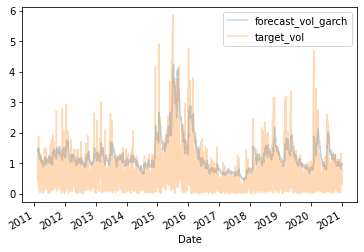

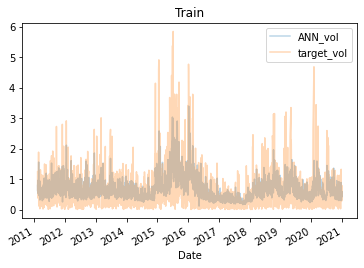

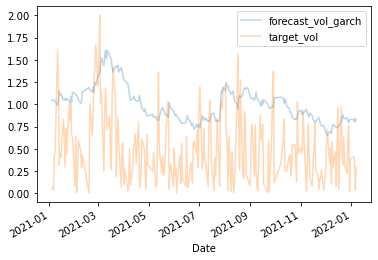

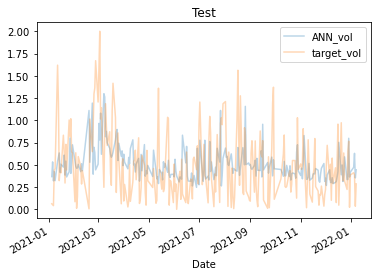

In [ ]:
stock = 'China'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)

In [ ]:
# R-Squared: 0.33 R-Squared: -0.039

# JAPAN

In [26]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.38546985492355085
MSE: 0.2842065603330819
RMSE: 0.5331102703316472
R-Squared: 0.3721799261812263


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.7138234974178634
MSE: 0.7422985291610781
RMSE: 0.8615674838113833
R-Squared: -0.6397577762712501




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.41635237521808965
MSE: 0.2924167818531015
RMSE: 0.5407557506426552
R-Squared: 0.04433547516396752


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.71695072748331
MSE: 0.6728573321466325
RMSE: 0.8202788136643738
R-Squared: -1.1990047169433065




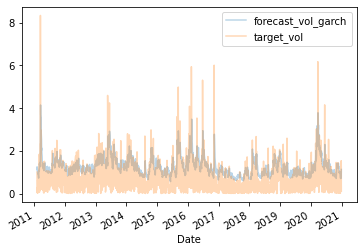

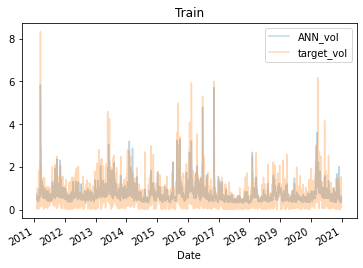

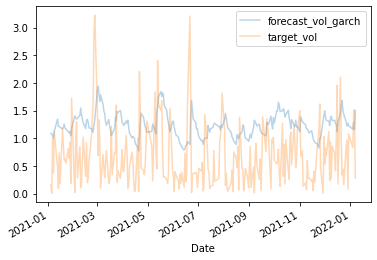

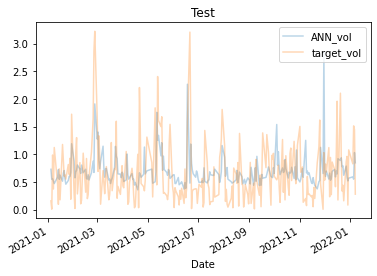

In [ ]:
stock = 'Japan'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)
# R-Squared: 0.372 R-Squared: -0.044

# HONGKONG

In [36]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.3412693058812426
MSE: 0.22036608453032547
RMSE: 0.4694316611928998
R-Squared: 0.23893196125751082


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.61919799723164
MSE: 0.5223667320188152
RMSE: 0.722749425471107
R-Squared: -0.8040735491997808




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.40596784307472533
MSE: 0.3042280105317387
RMSE: 0.5515686816088625
R-Squared: 0.052007505420952116


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.6811662990378485
MSE: 0.5986189400346162
RMSE: 0.773704685286716
R-Squared: -0.8653320622049627




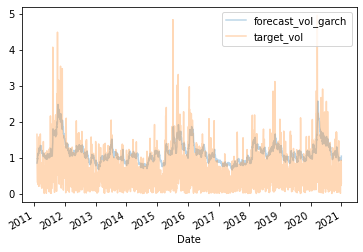

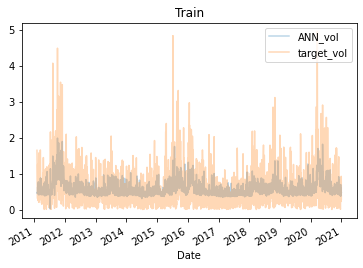

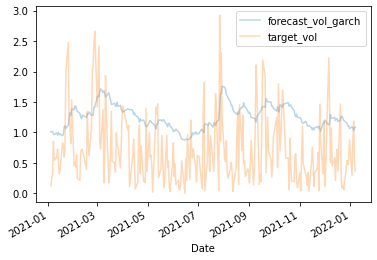

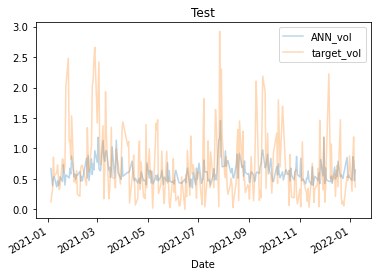

In [ ]:
stock = 'Hongkong'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)

# SINGAPORE

In [44]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.2547222836050502
MSE: 0.13464450409690168
RMSE: 0.366939373871082
R-Squared: 0.30384033415765677


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.4489287059465663
MSE: 0.29833432053435294
RMSE: 0.5461998906392722
R-Squared: -0.5424938602991727




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.24874369793868412
MSE: 0.10590096416339276
RMSE: 0.32542428330318673
R-Squared: 0.11850583740488341


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.4205012327513604
MSE: 0.24092459228018626
RMSE: 0.49084069949443504
R-Squared: -1.0053983776099065




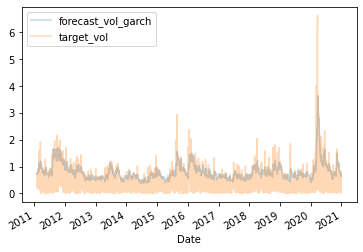

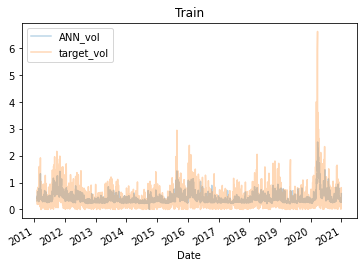

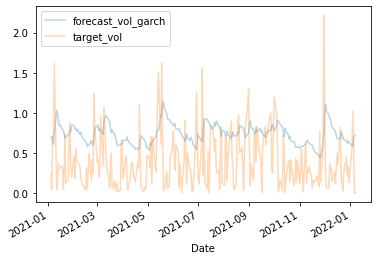

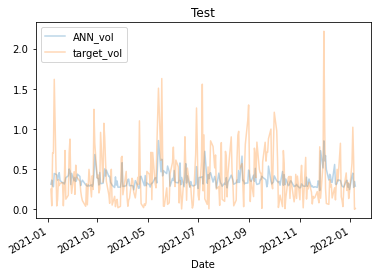

In [ ]:
stock = 'Singapore'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)

In [ ]:
# R-Squared: 0.33 R-Squared: 0.11

# KOREA

In [49]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.29319238347327986
MSE: 0.18450885142892975
RMSE: 0.42954493528492427
R-Squared: 0.33689783440837673


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.5246704225058849
MSE: 0.4150537017328798
RMSE: 0.6442466156161628
R-Squared: -0.4916520607246011




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.32222932541228755
MSE: 0.20984838077112367
RMSE: 0.4580921094835881
R-Squared: 0.1514894932765708


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.6029715551422187
MSE: 0.48384292340043983
RMSE: 0.6955881852076269
R-Squared: -0.9563925277880723




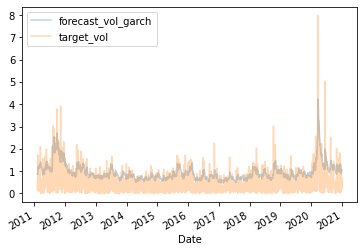

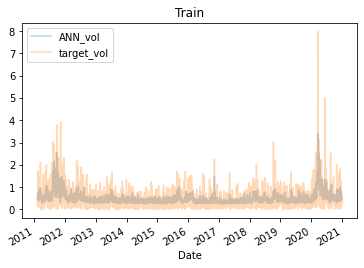

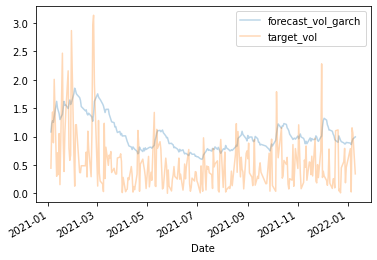

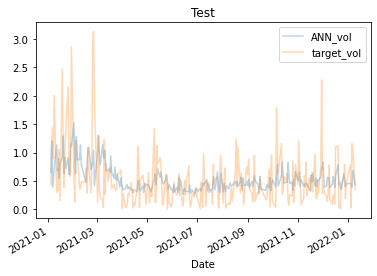

In [ ]:
stock = 'Korea'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)

In [ ]:
# R-Squared: 0.33 R-Squared:   0.15

# INDONESIA

In [54]:
def get_model(X_train):
        # Instantiate a Sequential model
    model = Sequential()
    # Add a Dense layer with 50 neurons and an input of 1 neuron
    model.add(Dense(50, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(50,activation='relu'))
    model.add(Dropout(0.2))
    # End your model with a Dense layer and no activation
    model.add(Dense(1))
    return model

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.3054213954899313
MSE: 0.18987736083313442
RMSE: 0.435749194873765
R-Squared: 0.334940262774432


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.5692132770055779
MSE: 0.46820448013650695
RMSE: 0.6842546895246733
R-Squared: -0.6399214059071812




ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.27236903624151787
MSE: 0.12868452530149027
RMSE: 0.3587262539897105
R-Squared: 0.0902382813019843


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.5190261543927718
MSE: 0.3624340854099401
RMSE: 0.6020249873634317
R-Squared: -1.562302310124557




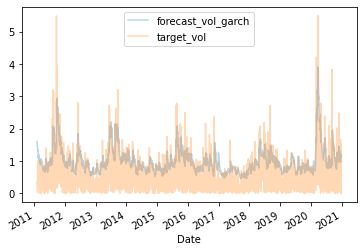

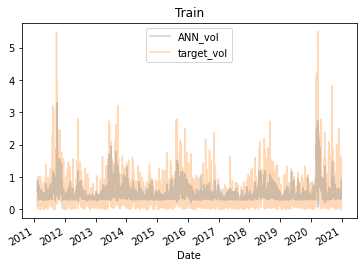

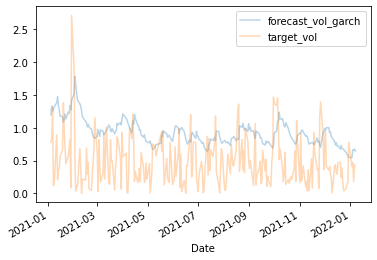

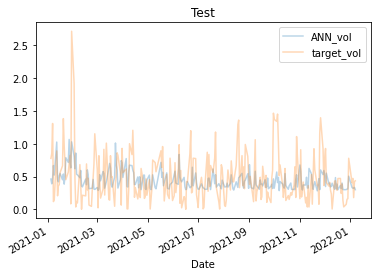

In [ ]:
stock = 'Indonesia'
X_train,X_test,df_train,df_test = implement_algo(stock)
df_train,df_test = model_predict(stock,X_train,X_test,df_train,df_test)

evaluate_vol_prediction(df_train,df_test)

In [ ]:
# R-Squared: 0.33 R-Squared: 0.09

ANN Prediction Train
Results of sklearn.metrics:
MAE: 0.008170463728976781
MSE: 0.0039367092156403355
RMSE: 0.06274320055305065
R-Squared: -138.67618514580585


Garch Prediction Train
Results of sklearn.metrics:
MAE: 0.005625090282314264
MSE: 4.59407283945114e-05
RMSE: 0.0067779590139297385
R-Squared: -0.6299973743225047
ANN Prediction Test
Results of sklearn.metrics:
MAE: 0.003115677726695785
MSE: 2.256964662557956e-05
RMSE: 0.004750752216815728
R-Squared: -0.5855792629005241


Garch Prediction Test
Results of sklearn.metrics:
MAE: 0.005208415224561881
MSE: 3.642399536991922e-05
RMSE: 0.006035229520898043
R-Squared: -1.5588850675700638


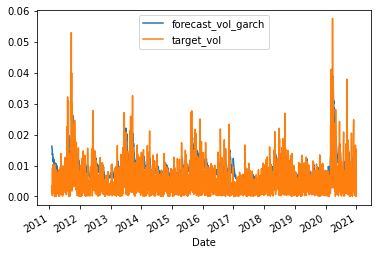

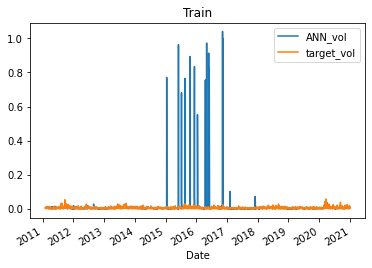

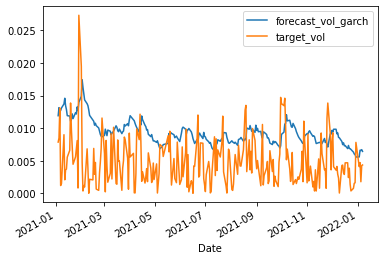

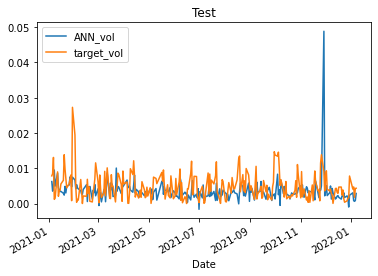

In [269]:
df_train,df_test = model_predict('China',X_train,X_test,df_train,df_test)
evaluate_vol_prediction(df_train,df_test)